# 📈 Clustering y Data Drift en tráfico web: guía práctica y razonada

Este cuaderno guía el flujo completo para: 1) preparar datos de tráfico web diarios, 2) medir cambio de distribución (data drift) entre dos periodos con PSI y KS, y 3) construir un clustering no supervisado (K-Means) sobre una ventana base para perfilar patrones. Más allá del “cómo”, explicamos el “por qué”: por qué convertir fechas y crear una columna de año, por qué limpiar números con separadores, por qué fijar bins de PSI con el baseline, y por qué escalar antes de K-Means. El objetivo es que puedas replicar el análisis, justificar decisiones y comunicar hallazgos a audiencias técnicas y de negocio.

## 🎯 Objetivos del cuaderno
- Preparar y validar datos de tráfico web con fechas en formato mes/día/año y columnas numéricas con separadores.
- Medir data drift entre dos años comparando distribuciones de variables clave mediante PSI y KS.
- Seleccionar y justificar una ventana base para entrenar K-Means, escalar variables y explorar un rango de k con elbow y silhouette.
- Interpretar resultados: qué significa un PSI alto, cómo leer p‑values de KS, y cómo traducir clusters a perfiles accionables.

In [165]:
import pandas as pd
import numpy as np 
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

## 🧰 Librerías y glosario mínimo
- pandas/numpy: manipulación de datos y cálculos numéricos.
- scikit-learn: StandardScaler para escalar variables y KMeans para clustering.
- scipy.stats: prueba KS para comparar distribuciones continuas.
- PSI (Population Stability Index): métrica que compara cómo se distribuye una variable en dos periodos. Se calcula sobre bins fijos (definidos con el baseline) y resume el cambio en un único número.

Reglas de lectura útiles:
- PSI < 0.10 cambios leves; 0.10–0.25 cambio moderado; > 0.25 cambio alto que merece investigación.
- En KS, p < 0.05 sugiere que las distribuciones difieren estadísticamente.

In [166]:
df = pd.read_csv('daily-website-visitors.csv', encoding='latin-1')
df.shape

(2167, 8)

## 📦 Carga de datos y validación básica
Leemos el CSV con codificación `latin-1` por compatibilidad con caracteres especiales. Antes de cualquier análisis, conviene inspeccionar dimensiones (`shape`) y primeras filas para identificar columnas relevantes, formatos de fecha y posibles caracteres no numéricos en métricas.

In [167]:
df.head(5)

,Row,Day,Day.Of.Week,Date,Page.Loads,Unique.Visits,First.Time.Visits,Returning.Visits
0,1,Sunday,1,9/14/2014,"2,146","1,582","1,430",152
1,2,Monday,2,9/15/2014,"3,621","2,528","2,297",231
2,3,Tuesday,3,9/16/2014,"3,698","2,630","2,352",278
3,4,Wednesday,4,9/17/2014,"3,667","2,614","2,327",287
4,5,Thursday,5,9/18/2014,"3,316","2,366","2,130",236


In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2167 entries, 0 to 2166
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Row                2167 non-null   int64 
 1   Day                2167 non-null   object
 2   Day.Of.Week        2167 non-null   int64 
 3   Date               2167 non-null   object
 4   Page.Loads         2167 non-null   object
 5   Unique.Visits      2167 non-null   object
 6   First.Time.Visits  2167 non-null   object
 7   Returning.Visits   2167 non-null   object
dtypes: int64(2), object(6)
memory usage: 135.6+ KB


In [169]:
df['fecha'] = pd.to_datetime(df['Date'].astype(str).str.strip(), format='%m/%d/%Y', errors='coerce')
df['year'] = df['fecha'].dt.year
print(df.year.value_counts())



year
2016    366
2015    365
2017    365
2018    365
2019    365
2020    232
2014    109
Name: count, dtype: int64


## 🗓️ Fechas y periodos de comparación
Convertimos `Date` a tipo fecha con formato mes/día/año (`%m/%d/%Y`) y creamos `year`. Esto posibilita seleccionar periodos comparables (p. ej., 2018 vs 2020) y detectar cambios estacionales o estructurales. Usamos `errors='coerce'` para transformar valores inválidos en NaN y evitar fallos.

In [170]:
df = df[['Page.Loads','Unique.Visits','First.Time.Visits','Returning.Visits','year']]
df = df.replace({r'[^\d\.-]':''}, regex=True) 
df = df.apply(pd.to_numeric, errors='coerce') 
df

,Page.Loads,Unique.Visits,First.Time.Visits,Returning.Visits,year
0,2146,1582,1430,152,2014
1,3621,2528,2297,231,2014
2,3698,2630,2352,278,2014
3,3667,2614,2327,287,2014
4,3316,2366,2130,236,2014
...,...,...,...,...,...
2162,2221,1696,1373,323,2020
2163,2724,2037,1686,351,2020
2164,3456,2638,2181,457,2020
2165,3581,2683,2184,499,2020


## 🧹 Limpieza y tipado de métricas numéricas
Seleccionamos métricas clave y removemos cualquier carácter no numérico (comas, puntos de miles, símbolos) con una expresión regular. Luego convertimos a números con coerción para evitar errores. Este paso es crítico: PSI y KS requieren comparaciones cuantitativas consistentes; valores como "1,234" deben convertirse a 1234.

In [171]:
cols = ['Page.Loads','Unique.Visits','First.Time.Visits','Returning.Visits']

baseline = 2018
target   = 2020  # cambia al año que quieras comparar

# Subconjuntos para drift (PSI/KS)
A = df.loc[df['year'] == baseline, cols].dropna()
B = df.loc[df['year'] == target,   cols].dropna()

print(A.shape, B.shape)

(365, 4) (232, 4)


## 🧭 Elección de baseline y periodo objetivo
Definimos un año baseline (referencia) y un año objetivo para comparar. El baseline debe ser un periodo “representativo” del comportamiento esperado. Creamos subconjuntos A y B y verificamos tamaños para evitar comparar arrays vacíos. Si alguna variable queda sin datos en un periodo, es mejor cambiar el año o imputar con cautela.

In [172]:
n_bins = 10
eps = 1e-8
rows=[]

for c in cols:
    a = A[c].values
    b = B[c].values
    # bordes por cuantiles del baseline
    edges = np.unique(np.quantile(a, np.linspace(0,1,n_bins+1)))
    if edges.size < 3:  # fallback si pocos valores únicos
        lo, hi = min(a.min(), b.min()), max(a.max(), b.max()) + eps
        edges = np.linspace(lo, hi, n_bins+1)
    pa = np.histogram(a, bins=edges)[0] / len(a)
    pb = np.histogram(b, bins=edges)[0] / len(b)
    pa = np.where(pa==0, eps, pa); pb = np.where(pb==0, eps, pb)
    psi_val = np.sum((pa - pb) * np.log(pa / pb))

    ks_stat, ks_p = ks_2samp(a, b)

    rows.append([c, psi_val, ks_stat, ks_p])

res = pd.DataFrame(rows, columns=['feature','PSI','KS_stat','KS_pvalue']).sort_values('PSI', ascending=False)
print(f"Comparación {baseline} (baseline) vs {target} (target)")
display(res)
print("Guía: PSI <0.10 estable, 0.10–0.25 moderado, >0.25 alto; KS p<0.05 sugiere cambio.")


Comparación 2018 (baseline) vs 2020 (target)


,feature,PSI,KS_stat,KS_pvalue
0,Page.Loads,1.823195,0.195583,3.112493e-05
3,Returning.Visits,0.645847,0.331660,2.394041e-14
2,First.Time.Visits,0.383045,0.183314,1.192321e-04
1,Unique.Visits,0.306333,0.119898,3.048928e-02


Guía: PSI <0.10 estable, 0.10–0.25 moderado, >0.25 alto; KS p<0.05 sugiere cambio.


## 📊 Métricas de drift: PSI y KS
- PSI: comparamos la distribución del baseline (A) con la del periodo objetivo (B) sobre los mismos bins. Definimos los bordes de bins con cuantiles de A para ser robustos a escalas y outliers, y aplicamos un fallback uniforme si hay pocos valores únicos. Sustituimos proporciones nulas por un epsilon para evitar log(0). El resultado resume el cambio en un número: a mayor PSI, mayor cambio.
- KS: contrasta si las distribuciones continuas difieren (estadístico máximo de la diferencia de CDFs). Reportamos el estadístico y el p‑value.

Interpretación combinada: PSI alto y KS con p < 0.05 refuerzan la evidencia de cambio real. Si discrepan, inspecciona histogramas; a veces PSI detecta cambios en colas donde KS es menos sensible, o viceversa.

### 🧠 Lectura de resultados de drift
Los resultados muestran PSI altos y p‑values de KS muy bajos para todas las métricas, lo que indica cambios sustanciales en la distribución del tráfico entre los años comparados. En términos de negocio, significa que el comportamiento de los usuarios (cargas de página, visitas únicas, primeras visitas y recurrentes) se redistribuyó de forma relevante. Esto sugiere revisar campañas, cambios en SEO, estacionalidad distinta o eventos externos que hayan alterado la demanda. Como siguiente paso, grafica histogramas A vs B y analiza qué segmentos (p. ej., fines de semana vs días laborables) contribuyen más al cambio.

In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2167 entries, 0 to 2166
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Page.Loads         2167 non-null   int64
 1   Unique.Visits      2167 non-null   int64
 2   First.Time.Visits  2167 non-null   int64
 3   Returning.Visits   2167 non-null   int64
 4   year               2167 non-null   int32
dtypes: int32(1), int64(4)
memory usage: 76.3 KB


In [174]:
df = df[df.year==2018]
print(df.year.value_counts())

year
2018    365
Name: count, dtype: int64


## 🧱 Ventana base para clustering
Para perfilar patrones, fijamos una ventana base (aquí 2018) y filtramos los datos a ese año. La idea es entrenar y entender clusters en un periodo “estable” y luego, si se desea, proyectar el modelo a otros años para comparar distribuciones de pertenencia. Evitamos incluir `year` como variable porque no describe el comportamiento, solo la partición temporal.

In [175]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

## ⚖️ Estandarización antes de K-Means
K-Means usa distancias euclídeas; si las variables están en magnitudes distintas, el centroide se sesga hacia la de mayor escala. StandardScaler centra y escala a varianza unitaria, haciendo que cada métrica aporte de forma comparable. Esta práctica mejora la estabilidad de los clusters y la interpretabilidad de los centroides.

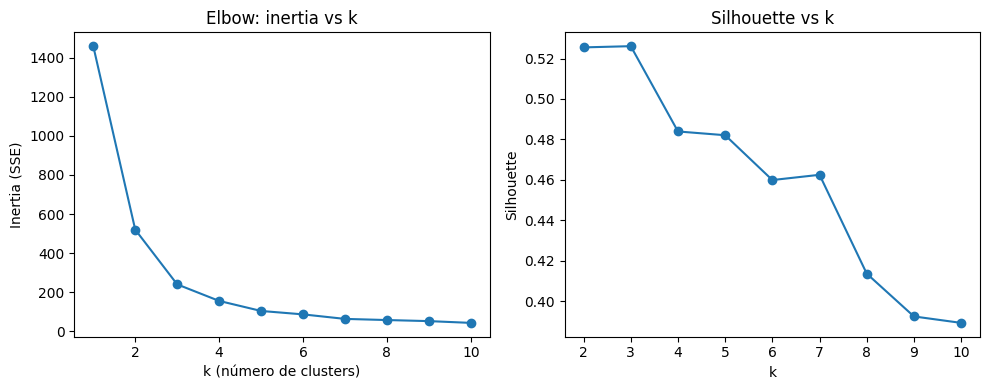

In [176]:
ks = list(range(1, 11)) # Probamos K del 1 al 10
inertias = []
sil_scores = []

for k in ks:
    km = KMeans(n_clusters=max(1,k), random_state=0).fit(X_scaled)
    inertias.append(km.inertia_)
    # silhouette sólo es válida si 2 <= n_clusters <= n_samples-1
    if 2 <= k <= X_scaled.shape[0] - 1:
        sil = silhouette_score(X_scaled, km.labels_)
    else:
        sil = np.nan
    sil_scores.append(sil)


plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(ks, inertias, marker='o')
plt.xlabel('k (número de clusters)')
plt.ylabel('Inertia (SSE)')
plt.title('Elbow: inertia vs k')

plt.subplot(1,2,2)
plt.plot(ks, sil_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Silhouette')
plt.title('Silhouette vs k')
plt.tight_layout()
plt.show()

## 🔎 Selección de k: Elbow y Silhouette
- Elbow (inertia/SSE): siempre decrece al aumentar k; buscamos un punto de rendimientos decrecientes (el “codo”), donde añadir más clusters apenas reduce el error.
- Silhouette: mide qué tan separadas y compactas están las clases; valores cercanos a 1 son mejores. Observa el pico o meseta alta y contrástalo con el codo. Si discrepan, prioriza la interpretabilidad de negocio: menos clusters con sentido suelen ganar frente a leves mejoras numéricas.

In [177]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)


## 🧪 Entrenamiento de K-Means y etiquetas
Entrenamos K-Means con un k ejemplar (3). En práctica, decide k observando elbow/silhouette y criterios de negocio (segmentos manejables, capacidad operativa). El objetivo es etiquetar cada día según un patrón de tráfico, útil para monitorear cómo cambian las proporciones de segmentos a lo largo del tiempo.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


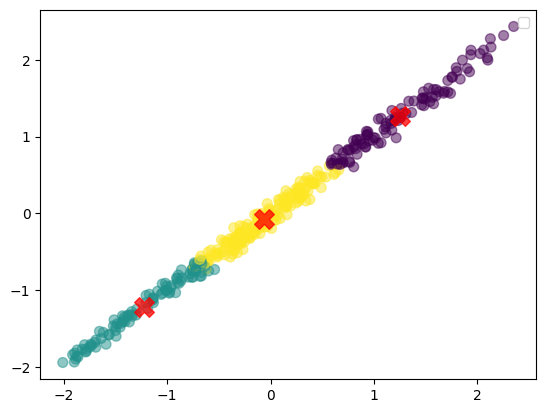

In [178]:
cluster_labels = kmeans.labels_

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=cluster_labels, cmap = "viridis", s= 50, alpha = 0.5)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c='red', s=200, alpha=0.75, marker='X')
plt.legend()
plt.show()

## 🗺️ Visualización y lectura de clusters
Graficamos los datos escalados coloreados por etiqueta, y superponemos los centroides (marcadores en rojo). Aunque trabajamos en 4 dimensiones, esta proyección 2D permite un vistazo rápido a la separación. Interpreta cada cluster revisando los centroides en el espacio original (invirtiendo el escalado si hace falta) y calculando estadísticas por grupo para traducirlos a perfiles de tráfico (picos de visitas únicas, predominio de recurrentes, etc.).